In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

This notebook focuses on Steps 1 and 2 of *Compare AI Exposure to AI Usage* and *Identify different AI transition archetypes* found in the [Concept Note](https://docs.google.com/document/d/1L5J0yp9uWzy_J4mkM9Ga62QGa-aa6oiG5bPMD9hmYCE/edit?usp=sharing) provided by Ms. Angela.

The granularity of the data is per SOC Occupation (where there 1,016 SOC occupations). However, due to privacy reasons (and also because apparently occupations related to military just really don't have data???), not all occupations have values (specifically on data which came from Anthropic.) They are held as null values.

# Step 1  - Compare AI Exposure to AI Usage

## a) Showing the Benefit of C-AIOE over AIOE

### Definition of the Data and Metrics
Before comparing the metrics, we first define what each measure represents and what we expect to observe in the correlation matrix.

1. `AIOE` is the AI Occupational Exposure index from the World Bank. Its values range from approximately 5 to 7 in our dataset. Since AIOE is an index, the absolute value is less important than the relative exposure of occupations to one another.

2. `Complementarity` measures the extent to which AI is expected to complement or augment human work rather than automate it. The metric ranges from 0% to 100%, with higher values indicating greater potential for augmentation.

3. `C-AIOE` is our complementarity-adjusted AIOE measure. We interpret this as a theoretical measure of a job's potential risk of being automated or replaced by AI. Since C-AIOE incorporates both AI exposure and complementarity, we expect it to increase as AIOE increases and decrease as complementarity increases.

4. `Observed Exposure` is based on Anthropic's observed Claude usage data and is defined as the share of a job being performed or accelerated by an LLM. Because Anthropic's methodology incorporates [automation into the calculation of Observed Exposure](https://cdn.sanity.io/files/4zrzovbb/website/e5f77fc0e77c0185110b5e4b909602791ae76eae.pdf), higher automation should correspond to higher observed exposure. We therefore interpret this as an observed measure of a job's potential AI automation risk.

### Motivation of Choosing C-AIOE over AIOE as the Main Metric to Compare Against Observed Exposure
The motivation for using C-AIOE rather than AIOE when comparing against Observed Exposure is that the two measures should be compared on a similar conceptual basis. AIOE captures AI exposure alone, whereas Observed Exposure incorporates both exposure to AI and the extent to which AI can automate the work. C-AIOE similarly combines AI exposure with complementarity to produce a single measure that accounts for both dimensions. In other words, Observed Exposure combines exposure and complementarity-related information into one observed measure, while C-AIOE combines exposure and complementarity into one theoretical measure. Comparing C-AIOE with Observed Exposure therefore provides a more conceptually comparable comparison than using AIOE alone.

### Granularity

Of the 1,016 SOC codes available for this analysis, 756 (74%) have complete data for AIOE, Complementarity, C-AIOE, and Observed Exposure. The correlation analysis and visualizations in this step therefore use these 756 occupations.

In [41]:
ai_metrics_df = pd.read_csv('../data/auxiliary/soc_consolidated_ai_metrics.csv')

exposure_df = ai_metrics_df[['O*NET-SOC Code', 'Title', 'AIOE', 'Complementarity', 'C-AIOE', 'Observed Exposure']].dropna()

## b) Showing that there exists a big difference between AIOE and C-AIOE

### Definition of the Data and Metrics
TL;DR: For all columns, a higher value generally indicates greater AI exposure or risk, except for `Complementarity`, where a higher value indicates greater potential for AI to complement rather than substitute human work.

1. `nth Top AIOE (AIOE Rank)`

Indicates an occupation's ranking based on its AIOE value, where `1` represents the occupation with the highest AIOE. A lower rank therefore indicates greater AI exposure.

2. `nth Top C-AIOE (C-AIOE Rank)`

Follows the same ranking convention as `nth Top AIOE (AIOE Rank)`, but uses the complementarity-adjusted AIOE (C-AIOE). A lower rank indicates greater AI exposure after accounting for complementarity.

3. `Increase in Exposure (Rank Change)`

Represents the change in an occupation's rank between AIOE and C-AIOE. A positive value indicates that the occupation moved to a higher numerical rank, while a negative value indicates movement toward a lower numerical rank.

4. `Increase in Exposure (Rank Change) Percent`

Represents the percentage change in an occupation's ranking after adjusting AIOE for complementarity. Its interpretation follows the direction of `Rank Change`, with positive values indicating movement toward a higher numerical rank and negative values indicating movement toward a lower numerical rank.

### Main Insight
1. Although the median and mean rank changes are -10 and 0, the changes are still nontrivial to the standard deviation being 193. Hence, we should actually check what are the differences.
2. The differences can be seen with looking at the top 5 an 

In [42]:
exposure_df["nth Top AIOE (AIOE Rank)"] = (
    exposure_df["AIOE"]
    .rank(ascending=False, method="min")
).astype(int)

exposure_df["nth Top C-AIOE (C-AIOE Rank)"] = (
    exposure_df["C-AIOE"]
    .rank(ascending=False, method="min")
).astype(int)

exposure_df["Increase in Exposure (Rank Change)"] = -(
    exposure_df["nth Top C-AIOE (C-AIOE Rank)"] - 
    exposure_df["nth Top AIOE (AIOE Rank)"]
)

exposure_df["Increase in Exposure (Rank Change) Percent"] = exposure_df["Increase in Exposure (Rank Change)"] / exposure_df["nth Top AIOE (AIOE Rank)"]
exposure_df = exposure_df.sort_values(by='Increase in Exposure (Rank Change) Percent', ascending=False)

In [43]:
exposure_df['Increase in Exposure (Rank Change)'].describe()

count    756.000000
mean       0.000000
std      193.166339
min     -553.000000
25%     -137.250000
50%      -10.000000
75%      130.000000
max      549.000000
Name: Increase in Exposure (Rank Change), dtype: float64

<Axes: >

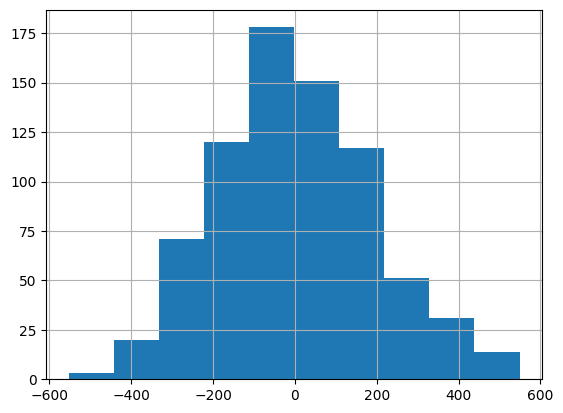

In [44]:
exposure_df['Increase in Exposure (Rank Change)'].hist()

In [45]:
# Identify the top 100 and bottom 100 AIOE occupations
top_100 = exposure_df[
    exposure_df["nth Top AIOE (AIOE Rank)"] <= 100
].copy()

bottom_100 = exposure_df[
    exposure_df["nth Top AIOE (AIOE Rank)"] >= (
        exposure_df["nth Top AIOE (AIOE Rank)"].max() - 99
    )
].copy()

# Add major group
major_groups = {
    "11": "Management",
    "13": "Business and Financial Operations",
    "15": "Computer and Mathematical",
    "17": "Architecture and Engineering",
    "19": "Life, Physical, and Social Science",
    "21": "Community and Social Service",
    "23": "Legal",
    "25": "Educational Instruction and Library",
    "27": "Arts, Design, Entertainment, Sports, and Media",
    "29": "Healthcare Practitioners and Technical",
    "31": "Healthcare Support",
    "33": "Protective Service",
    "35": "Food Preparation and Serving Related",
    "37": "Building and Grounds Cleaning and Maintenance",
    "39": "Personal Care and Service",
    "41": "Sales and Related",
    "43": "Office and Administrative Support",
    "45": "Farming, Fishing, and Forestry",
    "47": "Construction and Extraction",
    "49": "Installation, Maintenance, and Repair",
    "51": "Production",
    "53": "Transportation and Material Moving",
    "55": "Military"
}

In [46]:
aioe_top_100 = set(
    exposure_df.nlargest(
        100,
        "AIOE"
    )["O*NET-SOC Code"]
)

c_aioe_top_100 = set(
    exposure_df.nlargest(
        100,
        "C-AIOE"
    )["O*NET-SOC Code"]
)

top_100_major_group = pd.DataFrame({
    "AIOE Top 100": (
        exposure_df[
            exposure_df["O*NET-SOC Code"].isin(aioe_top_100)
        ]["O*NET-SOC Code"]
        .astype(str)
        .str[:2]
        .map(major_groups)
        .value_counts()
    ),
    "C-AIOE Top 100": (
        exposure_df[
            exposure_df["O*NET-SOC Code"].isin(c_aioe_top_100)
        ]["O*NET-SOC Code"]
        .astype(str)
        .str[:2]
        .map(major_groups)
        .value_counts()
    ),
}).fillna(0).astype(int)

top_100_major_group["Change"] = (
    top_100_major_group["C-AIOE Top 100"]
    - top_100_major_group["AIOE Top 100"]
)

top_100_major_group = top_100_major_group.sort_values(
    "Change",
    ascending=False
)

top_100_major_group

,AIOE Top 100,C-AIOE Top 100,Change
O*NET-SOC Code,,,
Office and Administrative Support,3,29,26
Computer and Mathematical,7,18,11
"Arts, Design, Entertainment, Sports, and Media",0,9,9
Production,0,4,4
Personal Care and Service,0,3,3
Sales and Related,2,3,1
Architecture and Engineering,7,6,-1
Legal,6,5,-1
Business and Financial Operations,19,15,-4


In [47]:
aioe_bottom_100 = set(
    exposure_df.nsmallest(
        100,
        "AIOE"
    )["O*NET-SOC Code"]
)

c_aioe_bottom_100 = set(
    exposure_df.nsmallest(
        100,
        "C-AIOE"
    )["O*NET-SOC Code"]
)

bottom_100_major_group = pd.DataFrame({
    "AIOE Bottom 100": (
        exposure_df[
            exposure_df["O*NET-SOC Code"].isin(aioe_bottom_100)
        ]["O*NET-SOC Code"]
        .astype(str)
        .str[:2]
        .map(major_groups)
        .value_counts()
    ),
    "C-AIOE Bottom 100": (
        exposure_df[
            exposure_df["O*NET-SOC Code"].isin(c_aioe_bottom_100)
        ]["O*NET-SOC Code"]
        .astype(str)
        .str[:2]
        .map(major_groups)
        .value_counts()
    ),
}).fillna(0).astype(int)

bottom_100_major_group["Change"] = (
    bottom_100_major_group["C-AIOE Bottom 100"]
    - bottom_100_major_group["AIOE Bottom 100"]
)

bottom_100_major_group = bottom_100_major_group.sort_values(
    "Change",
    ascending=False
)

bottom_100_major_group

,AIOE Bottom 100,C-AIOE Bottom 100,Change
O*NET-SOC Code,,,
Healthcare Practitioners and Technical,0,15,15
Protective Service,1,10,9
Transportation and Material Moving,10,18,8
"Installation, Maintenance, and Repair",13,16,3
"Life, Physical, and Social Science",0,1,1
Personal Care and Service,2,2,0
"Arts, Design, Entertainment, Sports, and Media",3,2,-1
Healthcare Support,2,1,-1
Office and Administrative Support,1,0,-1


## b) Recreating the Radial Bar Chart

TO-DO: RECREATE THE RADIAL BAR CHART


anyways, just in first view, it is a good that as the observed exposure increases, the C-AIOE increases too.

In [48]:
ai_metrics_df['Major Group'] = ai_metrics_df['O*NET-SOC Code'].str[:2].map(major_groups)

grouped_occupations_exposure = ai_metrics_df.groupby('Major Group')[['AIOE', 'C-AIOE', 'Observed Exposure']].mean()
grouped_occupations_exposure.sort_values(by='Observed Exposure')

,AIOE,C-AIOE,Observed Exposure
Major Group,,,
"Farming, Fishing, and Forestry",5.542649,4.257764,0.001845
Construction and Extraction,5.443713,3.871761,0.004038
Transportation and Material Moving,5.719272,4.070637,0.006452
"Installation, Maintenance, and Repair",5.632094,4.118862,0.007120
Production,5.660894,4.673299,0.007763
Food Preparation and Serving Related,5.660398,4.677273,0.009427
Protective Service,5.919943,4.101527,0.011876
Personal Care and Service,5.903980,4.494623,0.019148
Building and Grounds Cleaning and Maintenance,5.464392,4.251425,0.024737


# Step 2 - Identify different AI transition archetypes

## a) Choose how to identify the different AI transition archetypes

The eventual objective is to determine which approach provides a more useful basis for identifying AI transition archetypes. In particular, two approaches can be considered for comparing $\text{C-AIOE}$ with Observed Exposure.

1. The first approach is to transform $\text{C-AIOE}$ into a probability-scale measure so that it can be compared directly with Observed Exposure, which is already bounded between 0 and 1. Since the $\text{C-AIOE}$ distribution appears sufficiently bell-shaped, a normal-distribution transformation provides one possible approach. Each $\text{C-AIOE}$ score is first standardized into a z-score:

$$
z_j = \frac{\text{C-AIOE}j - \mu{\text{C-AIOE}}}{\sigma_{\text{C-AIOE}}}
$$

The resulting z-score is then converted using the cumulative distribution function of the standard normal distribution:

$$
P_j = \Phi(z_j)
$$

This produces a probability-scale representation of $\text{C-AIOE}$ that can be compared directly with Observed Exposure. Under this approach, the two measures speak to each other on a common probability scale, allowing the archetypes to be defined using their relative levels of $\text{C-AIOE}$ and Observed Exposure.

2. The second approach is to retain both measures in their original forms but compare their rankings across occupations. $\text{C-AIOE}$ and Observed Exposure can each be converted into occupation-level ranks, allowing the analysis to examine whether occupations that rank highly on one measure also rank highly on the other. Under this approach, the two measures speak to each other through their relative ordering, rather than through a common numerical scale.

These two approaches can then be compared based on which produces a more interpretable and meaningful classification of occupations into AI transition archetypes. The probability-based approach treats $\text{C-AIOE}$ and Observed Exposure as comparable measures on a common scale, while the rank-based approach treats them as proxies for the relative position of an occupation within each measure's distribution.

In [49]:
exposure_df["C-AIOE z-score"] = (
    exposure_df["C-AIOE"] - exposure_df["C-AIOE"].mean()
) / exposure_df["C-AIOE"].std()

exposure_df["C-AIOE Probability"] = norm.cdf(
    exposure_df["C-AIOE z-score"]
)

Text(0, 0.5, 'Observed Exposure')

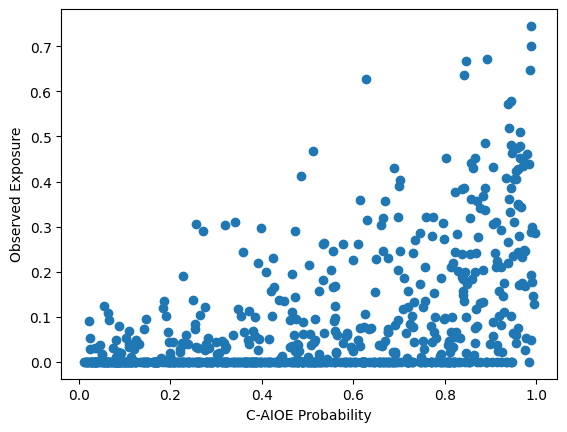

In [50]:
plt.scatter(exposure_df['C-AIOE Probability'], exposure_df['Observed Exposure'])
plt.xlabel('C-AIOE Probability')
plt.ylabel('Observed Exposure')

In [51]:
exposure_df["C-AIOE Rank"] = (
    exposure_df["C-AIOE"]
    .rank(ascending=False, method="min")
    .astype(int)
)

exposure_df["Observed Exposure Rank"] = (
    exposure_df["Observed Exposure"]
    .rank(ascending=False, method="min")
    .astype(int)
)

exposure_df["Rank Difference"] = (
    exposure_df["C-AIOE Rank"]
    - exposure_df["Observed Exposure Rank"]
)

In [52]:
exposure_df["Rank Difference"].describe()

count    756.000000
mean     111.453704
std      185.234283
min     -334.000000
25%      -21.250000
50%      105.000000
75%      263.000000
max      553.000000
Name: Rank Difference, dtype: float64

<Axes: >

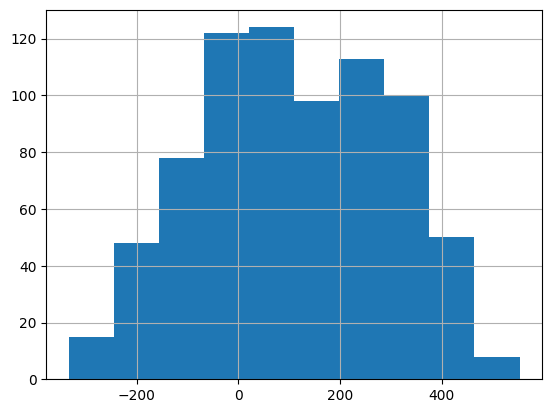

In [53]:
exposure_df["Rank Difference"].hist()

In [54]:
# Step 2 - Identimfy different AI transition archetypes